In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [80]:
df=pd.read_csv("healthcare_dataset.csv")


In [81]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            55500 non-null  str    
 8   Insurance Provider  55500 non-null  str    
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  str    
 12  Discharge Date      55500 non-null  str    
 13  Medication          55500 non-null  str    
 14  Test Results        55500 non-null  str    
dtypes: float64(1), int64(2), str(12)
memory usage: 6.4 MB


In [82]:
df.describe()
df["Gender"].value_counts
df["Test Results"].value_counts
df.isnull().sum()
df.duplicated().sum()


df[df.duplicated(keep=False)].head(20)
df[df.duplicated(keep=False)].sort_values("Name").head(20)
df[df.duplicated()].head(10)

df.loc[50023]
df[df.eq(df.loc[50023]).all(axis=1)]

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
6319,Samuel joYCe,56,Male,O+,Arthritis,03-11-2022,Krista Hartman,Thomas-Ballard,UnitedHealthcare,15654.83059,157,Urgent,22-11-2022,Aspirin,Inconclusive
50023,Samuel joYCe,56,Male,O+,Arthritis,03-11-2022,Krista Hartman,Thomas-Ballard,UnitedHealthcare,15654.83059,157,Urgent,22-11-2022,Aspirin,Inconclusive


In [83]:
df[df.duplicated(keep=False)].groupby(
    list(df.columns)
).size().value_counts().sort_index()
df = df.drop_duplicates()
df.shape
(df == "").sum()




Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [84]:
print(df["Gender"].value_counts())
print("\nBlood Type:")
print(df["Blood Type"].value_counts())
print("\nMedical Condition:")
print(df["Medical Condition"].value_counts())
print("\nAdmission Type:")
print(df["Admission Type"].value_counts())
print("\nTest Results:")
print(df["Test Results"].value_counts())
df["Admission Type"].value_counts()
df.select_dtypes(include="object").apply(
    lambda col: col.str.strip().ne(col).sum()
)

Gender
Male      27496
Female    27470
Name: count, dtype: int64

Blood Type:
Blood Type
A-     6898
A+     6896
B+     6885
AB+    6882
AB-    6874
B-     6872
O+     6855
O-     6804
Name: count, dtype: int64

Medical Condition:
Medical Condition
Arthritis       9218
Diabetes        9216
Hypertension    9151
Obesity         9146
Cancer          9140
Asthma          9095
Name: count, dtype: int64

Admission Type:
Admission Type
Elective     18473
Urgent       18391
Emergency    18102
Name: count, dtype: int64

Test Results:
Test Results
Abnormal        18437
Normal          18331
Inconclusive    18198
Name: count, dtype: int64


C:\Users\amanr\AppData\Local\Temp\ipykernel_17424\2125470611.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").apply(


Name                  0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [85]:
df["Date of Admission"].unique()[:10]
df["Discharge Date"].unique()[:10]
df["Discharge Date"].nunique()
df["Date of Admission"].nunique()
# df["Discharge Date"].unique()[:10]

1827

In [86]:
df["Date of Admission"] = pd.to_datetime(
    df["Date of Admission"],
    format="%d-%m-%Y"
)

df["Discharge Date"] = pd.to_datetime(
    df["Discharge Date"],
    format="%d-%m-%Y"
)
df[["Date of Admission", "Discharge Date"]].dtypes
df[["Date of Admission", "Discharge Date"]].isnull().sum()
df["Date of Admission"].head()
df["Length of Stay"] = df["Discharge Date"] - df["Date of Admission"]
df["Length of Stay"].head
df["Length of Stay"] = df["Length of Stay"].dt.days
# df["Length of Stay"].dtype
df["Length of Stay"].head
df["Length of Stay"].describe()

count    54966.000000
mean        15.499290
std          8.661471
min          1.000000
25%          8.000000
50%         15.000000
75%         23.000000
max         30.000000
Name: Length of Stay, dtype: float64

In [87]:
df["Age"].min(), df["Age"].max()
df["Length of Stay"].min(), df["Length of Stay"].max()
df["Length of Stay"].value_counts().sort_index().head(20)

(df["Age"] <= 0).sum()
df["Billing Amount"].min(), df["Billing Amount"].max()
(df["Billing Amount"] < 0).sum()
df[df["Billing Amount"] < 0][
    ["Name", "Age", "Medical Condition", "Billing Amount", "Admission Type"]
].head(20)
df.loc[df["Billing Amount"] < 0, "Billing Amount"].describe()
df[df["Billing Amount"] < 0][
    ["Name", "Age", "Medical Condition", "Billing Amount", "Admission Type"]
].head(20)

,Name,Age,Medical Condition,Billing Amount,Admission Type
132,ashLEy ERIcKSoN,32,Cancer,-502.507813,Urgent
799,CHRisTOPHer wEiss,49,Asthma,-1018.245371,Elective
1018,AsHley WaRnER,60,Hypertension,-306.364925,Elective
1421,JAY galloWaY,74,Asthma,-109.097122,Emergency
2103,josHUa wilLIamSon,72,Diabetes,-576.727907,Urgent
2696,Scott VaZqUEz,74,Diabetes,-135.986000,Elective
2855,CaROl aNDErSoN,39,Hypertension,-370.983674,Elective
3772,mr. ChRIStOPhER aLvARaDO,77,Obesity,-1310.272895,Elective
5445,ALExAndrA KHaN,32,Arthritis,-692.408820,Elective
5708,JosEPh cOx,23,Diabetes,-353.865186,Elective


In [88]:
df["Negative Billing"] = df["Billing Amount"] < 0
df["Negative Billing"].value_counts()
df["Age"].min(), df["Age"].max()
(df["Age"] > 100).sum()
(df["Age"] <= 0).sum()
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")


In [92]:
df.head(10)
df.info()
df.columns.tolist()

<class 'pandas.DataFrame'>
Index: 54966 entries, 0 to 55499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   name                54966 non-null  str           
 1   age                 54966 non-null  int64         
 2   gender              54966 non-null  str           
 3   blood_type          54966 non-null  str           
 4   medical_condition   54966 non-null  str           
 5   date_of_admission   54966 non-null  datetime64[us]
 6   doctor              54966 non-null  str           
 7   hospital            54966 non-null  str           
 8   insurance_provider  54966 non-null  str           
 9   billing_amount      54966 non-null  float64       
 10  room_number         54966 non-null  int64         
 11  admission_type      54966 non-null  str           
 12  discharge_date      54966 non-null  datetime64[us]
 13  medication          54966 non-null  str           
 14  test_r

['name',
 'age',
 'gender',
 'blood_type',
 'medical_condition',
 'date_of_admission',
 'doctor',
 'hospital',
 'insurance_provider',
 'billing_amount',
 'room_number',
 'admission_type',
 'discharge_date',
 'medication',
 'test_results',
 'length_of_stay',
 'negative_billing']

Perform EDA

In [ ]:
df["gender"].value_counts()
df["gender"].value_counts(normalize=True) * 100
df.groupby("medical_condition")["billing_amount"].mean().sort_values(ascending=False)



medical_condition
Obesity         25804.361902
Diabetes        25660.478635
Asthma          25633.461696
Arthritis       25511.783246
Hypertension    25503.058720
Cancer          25152.322947
Name: billing_amount, dtype: float64

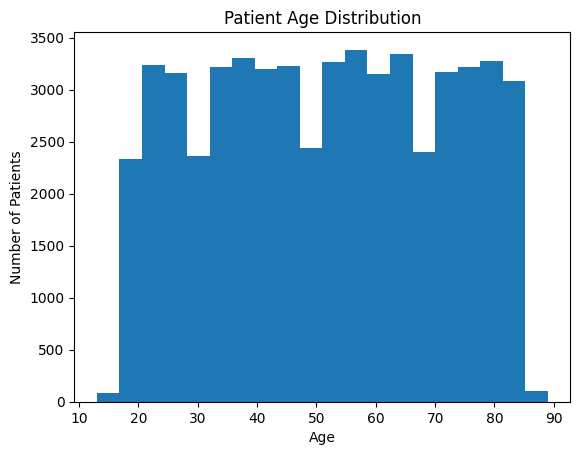

In [97]:
# Question: What is the age distribution of the patients?
import matplotlib.pyplot as plt

plt.hist(df["age"], bins=20)
plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

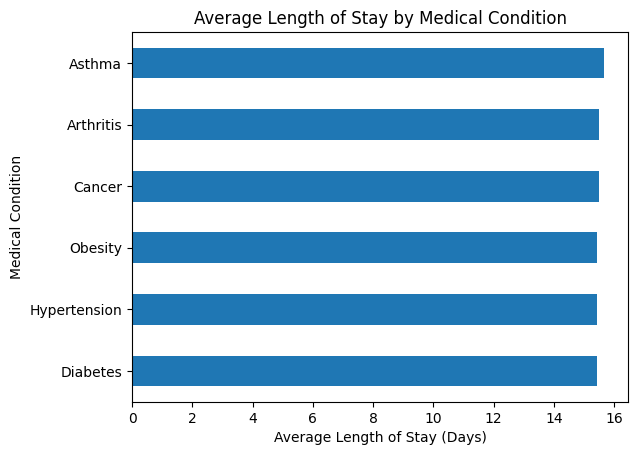

In [ ]:
# Question: Which medical conditions are associated with longer hospital stays?


df.groupby("medical_condition")["length_of_stay"].agg(
    ["count", "mean", "median", "min", "max"]
).sort_values("mean", ascending=False)


df.groupby("medical_condition")["length_of_stay"].mean().sort_values().plot(
    kind="barh"
)

plt.title("Average Length of Stay by Medical Condition")
plt.xlabel("Average Length of Stay (Days)")
plt.ylabel("Medical Condition")
plt.show()

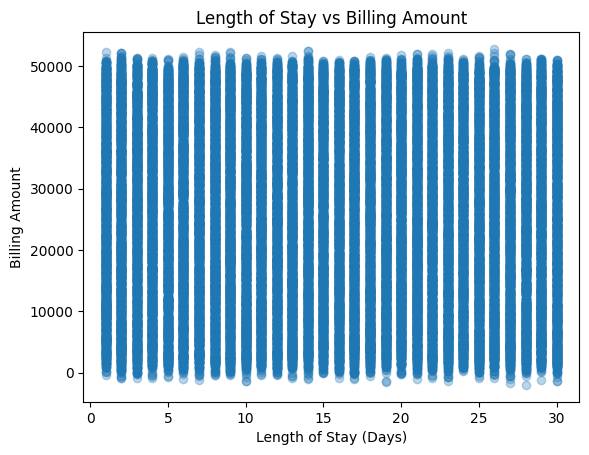

In [104]:
df[["length_of_stay", "billing_amount"]].corr()
plt.scatter(
    df["length_of_stay"],
    df["billing_amount"],
    alpha=0.3
)

plt.title("Length of Stay vs Billing Amount")
plt.xlabel("Length of Stay (Days)")
plt.ylabel("Billing Amount")
plt.show()

In [105]:
# Question: How do Emergency, Urgent, and Elective admissions differ in terms of billing and length of stay?

df.groupby("admission_type").agg(
    avg_billing=("billing_amount", "mean"),
    median_billing=("billing_amount", "median"),
    avg_stay=("length_of_stay", "mean"),
    patient_count=("name", "count")
).sort_values("avg_billing", ascending=False)

,avg_billing,median_billing,avg_stay,patient_count
admission_type,,,,
Elective,25612.139673,25674.73536,15.511178,18473
Urgent,25514.532045,25543.55847,15.403839,18391
Emergency,25505.332239,25413.78104,15.584134,18102


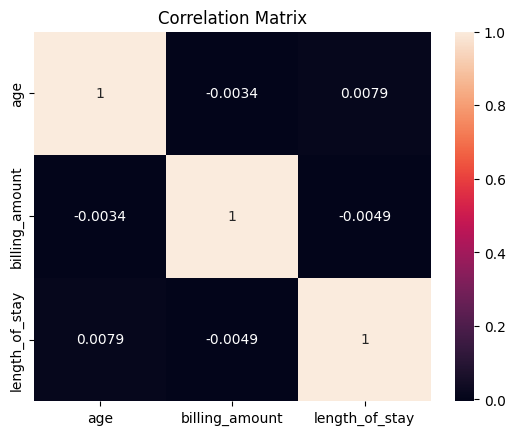

In [106]:
# Question: What is the relationship between Age, Billing Amount, and Length of Stay?

import seaborn as sns

sns.heatmap(
    df[["age", "billing_amount", "length_of_stay"]].corr(),
    annot=True
)

plt.title("Correlation Matrix")
plt.show()